In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from gan.models import Generator, Discriminator
from gan.training import train_gan

In [2]:


def make_gaussian_mixture(
    n_samples=50_000,
    centers=8,
    radius=5.0,
    std=0.5,
    seed=0
):
    """
    Create distribution of disk-like clusters centered at the origin
    Parameters
    ----------
    n_samples : int
        number of data points to be created
    centers : int   
        number of clusters to have
    radius : float
        distance to origin of cluster centers
    std : float
        standard deviation of distance of points to cluster center
    seed : int
        random seed
    Returns
    -------
    tuple(np.ndarray)
        array of points, array of centers for each point, array of labels for each point
    """
    rng = np.random.default_rng(seed)

    angles = np.linspace(0, 2*np.pi, centers, endpoint=False)
    means = np.stack([
        radius * np.cos(angles),
        radius * np.sin(angles)
    ], axis=1)

    samples = []
    sample_labels = []
    sample_centers = []
    for _ in range(n_samples):
        k = rng.integers(0, centers)
        sample_labels.append(k)
        sample_centers.append(means[k])
        x = rng.normal(loc=means[k], scale=std, size=2)
        samples.append(x)

    return np.array(samples, dtype=np.float32), np.array(sample_labels), np.array(sample_centers,dtype=np.float32)

In [3]:

# Create data and labels and points
X, c_label, c_center = make_gaussian_mixture()

In [4]:
# one hot encode the labels
one_hot = torch.nn.functional.one_hot(torch.tensor(c_label), num_classes=8).float()

In [5]:
# combine the centers and labels into one conditional vector
c = torch.cat([torch.tensor(c_center), one_hot], dim=1)

In [6]:
G = Generator(
    noise_dim = 2,
    num_hidden_layers = 2,
    out_dim = 2,
    hidden_dims=(128,128),
    use_conditional=True,
    conditional_dim=c.shape[1]
)

In [7]:
G_fm = Generator(
    noise_dim = 2,
    num_hidden_layers = 2,
    out_dim = 2,
    hidden_dims=(128,128),
    use_conditional=True,
    conditional_dim=c.shape[1]
)

In [8]:
D = Discriminator(
    feature_dim=2,
    num_hidden_layers=2,
    hidden_dims=(128,128),
    use_conditional=True,
    conditional_dim=c.shape[1]
)

In [9]:
D_fm = Discriminator(
    feature_dim=2,
    num_hidden_layers=2,
    hidden_dims=(128,128),
    use_conditional=True,
    conditional_dim=c.shape[1]
)

In [10]:
train_gan(
    X=torch.tensor(X),
    G=G,
    D=D,
    c=c
)

GAN training:   0%|          | 0/200 [00:00<?, ?it/s]

In [11]:
train_gan(
    X=torch.tensor(X),
    G=G_fm,
    D=D_fm,
    c=c,
    lambda_fm_1=0.01,
    lambda_fm_2=0.04,
    lambda_entropy=0.001
)

GAN training:   0%|          | 0/200 [00:00<?, ?it/s]

In [20]:

@torch.no_grad()
def plot_samples(G, X_real,c = None, n=2000, title=None):
    """
    plot fake and real points
    Parameters
    ----------
    G: Generator
        used to create fake points
    X_real: np.ndarray
        array of real data
    c : torch.Tensor | None
        if not none , the conditional to be used
    n: int
        nmber of points to be generated
    title : str | None
        optional string to be used for title of plot
    """
    if c is not None:
        c_input = c[:n]
    else: 
        c_input = None
    X_fake = G.generate(n, c_input).cpu().numpy()
    plt.figure(figsize=(5,5))
    plt.scatter(X_real[:n,0], X_real[:n,1], s=5, alpha=0.3, label="Real")
    plt.scatter(X_fake[:,0], X_fake[:,1], s=5, alpha=0.3, label="Fake")
    if title is not None:
        plt.title(title)
    plt.legend()
    plt.axis("equal")
    plt.show()

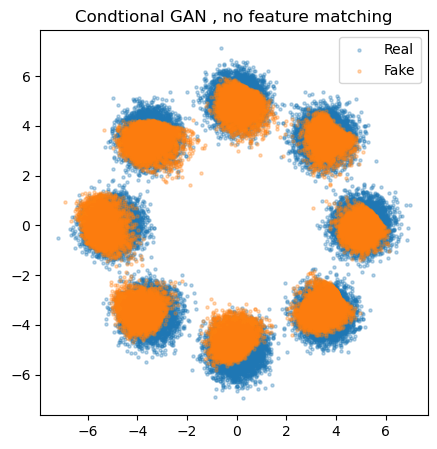

In [21]:
plot_samples(G, X, c, len(X), "Condtional GAN , no feature matching")

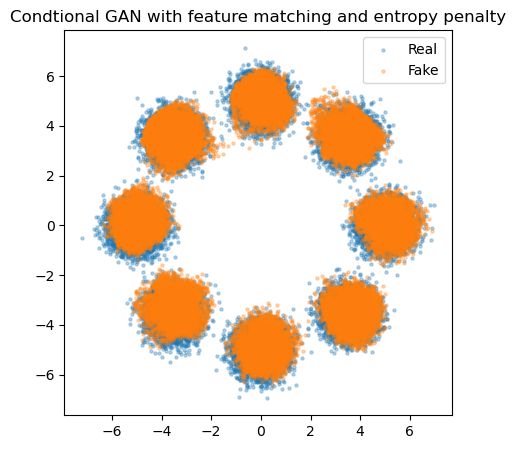

In [22]:
plot_samples(G_fm, X, c, len(X), "Condtional GAN with feature matching and entropy penalty")

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

In [24]:
def roc(G, X, c = None):
    if c is not None:
        X_fake = G.generate(len(c), c).cpu().detach().numpy()
    else:
        X_fake = G.generate(len(X)).cpu().detach().numpy()
    target_real = np.ones(len(X))
    target_fake = np.zeros(len(X_fake))
    if c is not None:
        X_c = np.hstack([X,c.cpu().detach().numpy()])
        X_fake_c = np.hstack([X_fake,c.cpu().detach().numpy()])
    else:
        X_c = X
        X_fake_c = X_fake
    X_full = np.vstack([X_c,X_fake_c])
    y = np.concat([target_real, target_fake])
    X_train, X_test, y_train, y_test= train_test_split(X_full,y,test_size=0.2, stratify=y,random_state=42)
    rf = RandomForestClassifier(random_state=42)
    rf.fit(X_train, y_train)
    y_prob = rf.predict_proba(X_test)[:,1]
    return roc_auc_score(y_test, y_prob)

In [25]:

def roc_robust(G, X, c=None, n_repeats=5, random_state=42):
    """
    Computes ROC-AUC for distinguishing real vs generated data,
    repeating the evaluation multiple times for stability.

    Parameters:
        G          : Generator with a .generate method
        X          : Real data (numpy array or torch tensor)
        c          : Optional condition array
        n_repeats  : Number of repeated train/test splits
        random_state : Seed for reproducibility

    Returns:
        mean_auc : Mean ROC-AUC across repeats
        std_auc  : Standard deviation of ROC-AUC across repeats
    """
    # Generate fake data
    if c is not None:
        X_fake = G.generate(len(c), c).cpu().detach().numpy()
    else:
        X_fake = G.generate(len(X)).cpu().detach().numpy()

    # Labels
    target_real = np.ones(len(X))
    target_fake = np.zeros(len(X_fake))
    if c is not None:
        X_c = np.hstack([X,c.cpu().detach().numpy()])
        X_fake_c = np.hstack([X_fake,c.cpu().detach().numpy()])
    else:
        X_c = X
        X_fake_c = X_fake
    # Combine
    X_full = np.vstack([X_c, X_fake_c])
    y = np.concat([target_real, target_fake])

    aucs = []

    # Repeat evaluation
    rng = np.random.default_rng(random_state)
    for _  in range(n_repeats):
        # Shuffle the data differently each time
        X_train, X_test, y_train, y_test = train_test_split(
            X_full, y, test_size=0.2, stratify=y,
            random_state=rng.integers(0, 1_000_000)
        )
        rf = RandomForestClassifier(random_state=rng.integers(0, 1_000_000))
        rf.fit(X_train, y_train)
        y_prob = rf.predict_proba(X_test)[:,1]
        auc = roc_auc_score(y_test, y_prob)
        aucs.append(auc)

    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)
    return mean_auc, std_auc


In [26]:
roc_robust(G, X, c)

(np.float64(0.65981859), np.float64(0.0028863404605676997))

In [27]:
roc_robust(G_fm, X, c)

(np.float64(0.548786708), np.float64(0.002853242826516144))